This is the Quality control step of crc-pm

In [36]:
# modules
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import scipy as sp
from scipy.sparse import csr_matrix
from scipy.stats import median_abs_deviation
from pathlib import Path
import sys
import re
import os
import seaborn as sns
import scvi
### Import personal Utensils
sys.path.insert(0, "..")
import utils as ut

In [37]:
# read data
CuratedDir = Path("../../result/curated/merged.h5ad")
adata = sc.read_h5ad(CuratedDir)
adata.X = adata.layers['counts']

### Remove ambient RNA
module off: in crc-atlas, only those with empty droplet profile were applied scAR

In [38]:
# #####
# # AIGC: out of memory, ask AI to fix
# #####

# # SCAR ambient-RNA correction:
# # train per sequencing sample; export denoised counts in small sparse chunks

# import gc
# import torch
# from scipy import sparse
# from scipy.sparse import csr_matrix

# # 此时 filter_cells 已完成。释放 X，避免后续 sub 同时持有 X 和 counts layer。
# adata.X = None

# export_chunk_size = 512       # controls CPU/RAM peak during export
# inference_batch_size = 128    # controls GPU peak during forward pass

# sample_values = adata.obs["Glob_Sample"].astype(str).to_numpy()
# sample_blocks = []
# sample_row_indices = []

# for sample in pd.unique(sample_values):
#   idx = np.flatnonzero(sample_values == sample)

#   # 只创建一份该 sample 的 raw-count matrix，放在 .X 中供 SCAR 使用
#   sub = ad.AnnData(
#       X=adata.layers["counts"][idx, :].copy(),
#       obs=adata.obs.iloc[idx].copy(),
#       var=adata.var.copy(),
#   )

#   # 一个 sub 就是一个 library/sample；不再跨 sample 共用 ambient profile
#   scvi.external.SCAR.setup_anndata(sub)

#   model = scvi.external.SCAR(
#       sub,
#       ambient_profile=None,
#   )
#   model.train(accelerator="gpu")

#   chunks = []
#   for start in range(0, sub.n_obs, export_chunk_size):
#       stop = min(start + export_chunk_size, sub.n_obs)

#       chunk = sub[start:stop].copy()
#       dense = model.get_denoised_counts(
#           adata=chunk,
#           batch_size=inference_batch_size,
#       )

#       corrected = csr_matrix(dense, dtype=np.int32)
#       corrected.eliminate_zeros()
#       chunks.append(corrected)

#       del chunk, dense, corrected

#   sample_blocks.append(sparse.vstack(chunks, format="csr"))
#   sample_row_indices.append(idx)

#   print(f"{sample}: {sub.n_obs:,} cells done")

#   del chunks, model, sub
#   gc.collect()
#   torch.cuda.empty_cache()

# # sample 的细胞可能不连续；拼接后恢复为 adata 原始行顺序
# stacked = sparse.vstack(sample_blocks, format="csr")
# stacked_row_order = np.concatenate(sample_row_indices)

# restore_order = np.empty(adata.n_obs, dtype=np.int64)
# restore_order[stacked_row_order] = np.arange(adata.n_obs)

# denoised_rna = stacked[restore_order].tocsr()

# del sample_blocks, sample_row_indices, stacked, stacked_row_order, restore_order
# gc.collect()

# adata.layers["denoised_rna"] = denoised_rna
# adata.X = denoised_rna

### Coarse QC

In [39]:
# mitochondrial genes
adata.var["mt"] = adata.var['gene_name'].str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var['gene_name'].str.startswith(("RPS", "RPL"))
# hemoglobin genes.
adata.var["hb"] = adata.var['gene_name'].str.contains(r"^HB[ABDEGMQZ]\d*(?!\w)")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True)

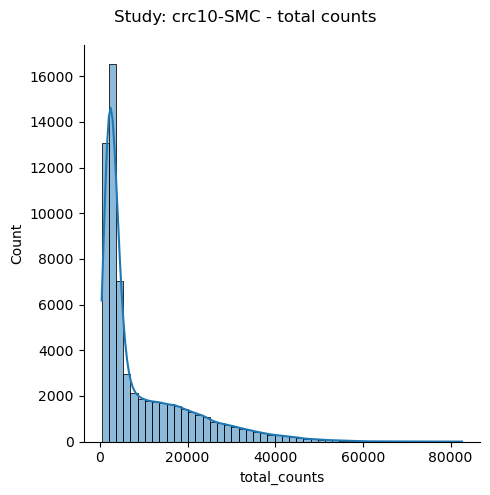

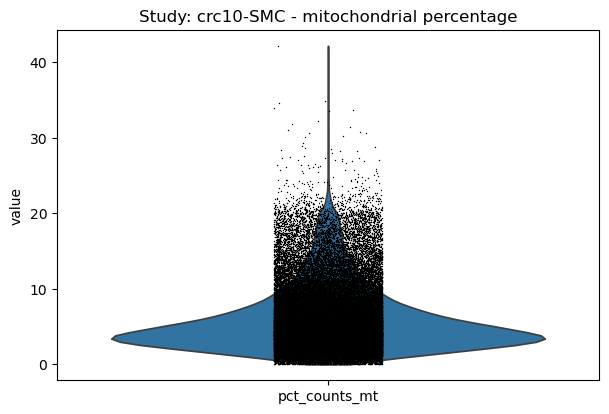

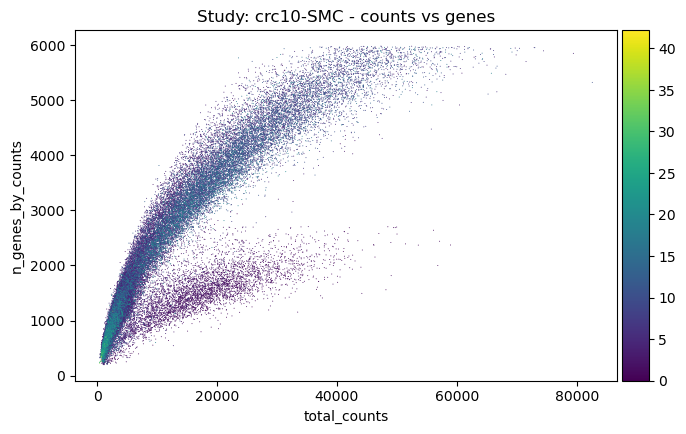

In [40]:
# Preview data quality by sample
ut.preview_cell_quality(adata, "Study",'crc10-SMC')

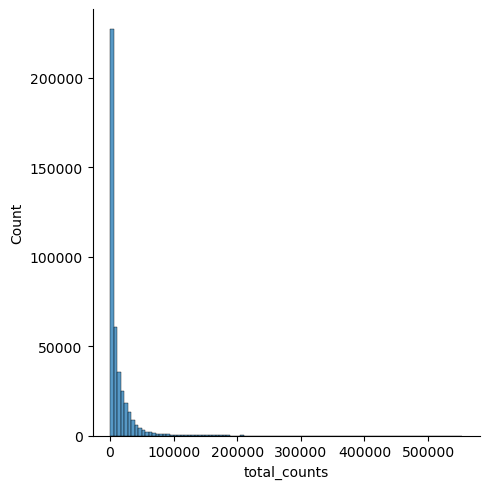

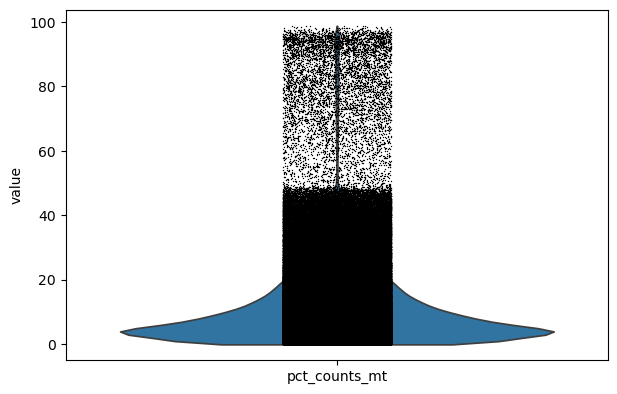

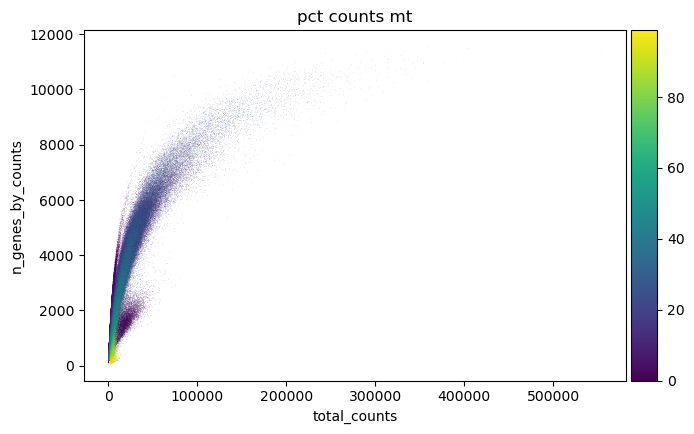

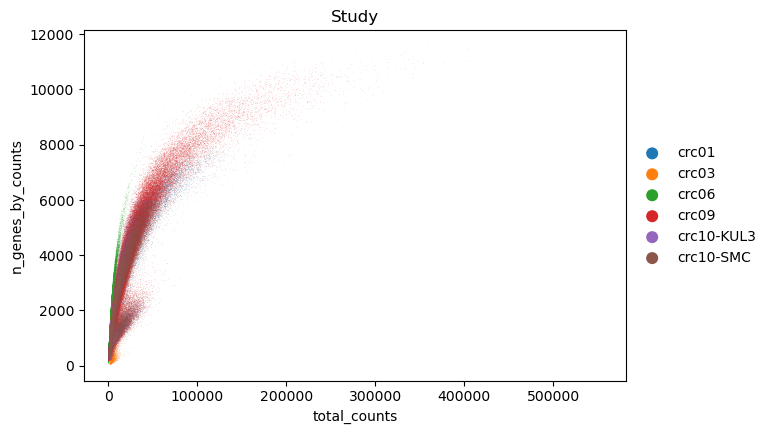

In [41]:
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")
p4 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="Study")

In [42]:
def is_outlier(adata, metric: str, nmads: int, groupby):
    M = adata.obs[metric]
    grouped = adata.obs.groupby(groupby,observed=True)[metric]
    median = grouped.transform("median")
    mad = grouped.transform(lambda x: median_abs_deviation(x, nan_policy="omit"))
    outlier = ((M < median - nmads * mad) | (M > median + nmads * mad))
    return outlier

In [43]:
# cell filtering
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5, groupby="Study")
    | is_outlier(adata, "log1p_n_genes_by_counts", 5, groupby="Study")
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5, groupby="Study")
)
adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3, groupby="Study") | (
    adata.obs["pct_counts_mt"] > 40)
# very hard to choose the mt threshold, as lots of cells in crc01 have high mt percentage
# while in crc06, almost no mt gene
# it is so decided that 40% should be should be the threshold

adata.obs["qc_outlier"] = adata.obs["outlier"] | adata.obs["mt_outlier"]

qc_summary = (
    adata.obs
    .groupby("Study", observed=True)["outlier"]
    .agg(total="size", removed="sum")
)
qc_summary["kept"] = qc_summary["total"] - qc_summary["removed"]
qc_summary["removed_pct"] = qc_summary["removed"] / qc_summary["total"] * 100

print(qc_summary)

             total  removed    kept  removed_pct
Study                                           
crc01        43841      849   42992     1.936543
crc03        18101      104   17997     0.574554
crc06        28661     1020   27641     3.558843
crc09       231737    11426  220311     4.930589
crc10-KUL3   27414     3216   24198    11.731232
crc10-SMC    63689     6725   56964    10.559123


In [44]:
# qc
adata = adata[~adata.obs["qc_outlier"]].copy()
# gene filtering
sc.pp.filter_genes(adata, min_cells=20)

### Doublet depletion

In [45]:
# adata.obs["Study_Tissue"] = adata.obs["Study"].astype(str) + "_" + adata.obs["Tissue"].astype(str)
# sc.pp.scrublet(
#     adata,
#     batch_key="Study_Tissue",
#     expected_doublet_rate=0.05,
#     random_state=0,
# )
# # here we use study_tissue as batch_key, because fucking crc01 contains some sample which literally has no fucking cells

In [46]:
import gc
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse


COUNT_LAYER = "counts"
BATCH_KEY = "Glob_Sample"
MIN_CELLS = 200


# 默认认为不是 doublet
# 对于细胞数不足的 sample, 将保持 False
adata.obs["predicted_doublet"] = False

# 没有运行 Scrublet 的细胞没有合法的 doublet score
adata.obs["doublet_score"] = np.nan


groups = adata.obs.groupby(
    BATCH_KEY,
    observed=True,
    sort=False,
).indices


for sample, idx in groups.items():

    idx = np.asarray(idx)
    obs_names = adata.obs_names[idx]
    n_cells = len(idx)

    print(f"{sample}: {n_cells} cells")

    # 太小的 sample 不运行 Scrublet
    # predicted_doublet 保持 False
    if n_cells < MIN_CELLS:
        print("  skipped: too few cells")
        continue

    # 只提取当前 sample 的 raw counts
    X = adata.layers[COUNT_LAYER][idx]

    if sparse.issparse(X):
        X = X.tocsr().copy()
    else:
        X = np.asarray(X, dtype=np.float32)

    # 创建轻量 AnnData
    # 不复制原 adata 的其他 layers / obsm / uns 等
    tmp = ad.AnnData(
        X=X,
        obs=pd.DataFrame(index=obs_names.copy()),
        var=pd.DataFrame(index=adata.var_names.copy()),
    )

    # 根据 sample 大小调整 PCA/SVD 维度
    if n_cells < 500:
        n_pcs = 10
    elif n_cells < 1000:
        n_pcs = 20
    else:
        n_pcs = 30

    try:
        sc.pp.scrublet(
            tmp,
            expected_doublet_rate=0.05,
            sim_doublet_ratio=2.0,
            mean_center=False,
            n_prin_comps=n_pcs,
            random_state=0,
        )

        adata.obs.loc[
            obs_names,
            "doublet_score",
        ] = tmp.obs["doublet_score"].to_numpy()

        adata.obs.loc[
            obs_names,
            "predicted_doublet",
        ] = tmp.obs["predicted_doublet"].to_numpy(dtype=bool)

        print(
            f"  predicted doublets: "
            f"{tmp.obs['predicted_doublet'].sum()} / {n_cells} "
            f"({tmp.obs['predicted_doublet'].mean():.2%})"
        )

    except Exception:
        # 真正运行失败时不要静默地把整个 sample 当作 singlet
        # 否则无法区分 "too few" 和 "算法失败"
        print(f"  FAILED: {sample}")
        raise

    finally:
        del tmp
        del X
        gc.collect()

crc01-crc1: 3940 cells
  predicted doublets: 0 / 3940 (0.00%)
crc01-crc10: 2570 cells
  predicted doublets: 2 / 2570 (0.08%)
crc01-crc2: 112 cells
  skipped: too few cells
crc01-crc3: 1965 cells
  predicted doublets: 0 / 1965 (0.00%)
crc01-crc4: 1908 cells
  predicted doublets: 2 / 1908 (0.10%)
crc01-crc5: 953 cells
  predicted doublets: 0 / 953 (0.00%)
crc01-crc6: 164 cells
  skipped: too few cells
crc01-crc7: 195 cells
  skipped: too few cells
crc01-crc8: 127 cells
  skipped: too few cells
crc01-crc9: 84 cells
  skipped: too few cells
crc01-crcl1: 2511 cells
  predicted doublets: 5 / 2511 (0.20%)
crc01-crcl2: 631 cells
  predicted doublets: 3 / 631 (0.48%)
crc01-pm1: 10222 cells
  predicted doublets: 0 / 10222 (0.00%)
crc01-pm10: 4486 cells
  predicted doublets: 1 / 4486 (0.02%)
crc01-pm2: 28 cells
  skipped: too few cells
crc01-pm3: 3521 cells
  predicted doublets: 0 / 3521 (0.00%)
crc01-pm4: 521 cells
  predicted doublets: 4 / 521 (0.77%)
crc01-pm5: 1038 cells
  predicted doublets:

In [47]:
print(f"Before: {adata.n_obs:,}")
print(f"Doublets: {adata.obs['predicted_doublet'].sum():,}")
print(f"Doublet rate: {adata.obs['predicted_doublet'].mean():.2%}")

Before: 341,282
Doublets: 737
Doublet rate: 0.22%


In [48]:
adata = adata[~adata.obs["predicted_doublet"]].copy()
print(f"After: {adata.n_obs:,}")

After: 340,545


### Export

In [49]:
adata = adata[~adata.obs["predicted_doublet"]].copy()
outdir = Path("../../result/qc")
adata.write_h5ad(outdir / "qc.h5ad", compression="lzf")